# Paso 1: Descarga del dataset

In [ ]:
# ============================================================
# CONFIGURAR TOKEN DE KAGGLE
# ============================================================

import os

TOKEN = "KGAT_c4967bf586bb1d97d883d83fdbdb14be"

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/access_token", "w") as f:
    f.write(TOKEN)

os.chmod("/root/.kaggle/access_token", 0o600)

# ============================================================
# DESCARGAR DATASET
# ============================================================

!kaggle datasets download \
-d soumendraprasad/fifa-2022-all-players-image-dataset

# ============================================================
# DESCOMPRIMIR
# ============================================================

!mkdir -p /content/FIFA_2022_ALL_PLAYERS

!unzip -q fifa-2022-all-players-image-dataset.zip \
-d /content/FIFA_2022_ALL_PLAYERS


Dataset URL: https://www.kaggle.com/datasets/soumendraprasad/fifa-2022-all-players-image-dataset
License(s): CC0-1.0
 83% 299M/361M [00:09<00:01, 33.7MB/s]
User cancelled operation
[fifa-2022-all-players-image-dataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of fifa-2022-all-players-image-dataset.zip or
        fifa-2022-all-players-image-dataset.zip.zip, and cannot find fifa-2022-all-players-image-dataset.zip.ZIP, period.


# Paso 2: Generacion del nuevo dataset con las imagenes de los rostros de los jugadores

In [ ]:
!pip install -q insightface onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 128.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 125.0 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import cv2
import numpy as np
from insightface.app import FaceAnalysis

# ==========================================
# CONFIGURACION
# ==========================================

DATASET_DIR = "/content/FIFA_2022_ALL_PLAYERS"
OUTPUT_DIR = "/content/FIFA_2022_ONLY_FACES"

IMG_SIZE = 224

# ==========================================
# CARGAR MODELO
# ==========================================

app = FaceAnalysis(
    providers=['CPUExecutionProvider'] #CUDAExecutionProvider --> Para correr con GPU
)

app.prepare(
    ctx_id=0,
    det_size=(640,640)
)

# ==========================================
# FUNCIONES
# ==========================================

def extract_face(img):

    faces = app.get(img)

    if len(faces) == 0:
        return None

    # tomar la cara mas grande
    face = max(
        faces,
        key=lambda f:
        (f.bbox[2]-f.bbox[0]) *
        (f.bbox[3]-f.bbox[1])
    )

    x1, y1, x2, y2 = map(int, face.bbox)

    h, w = img.shape[:2]

    padding = 15

    x1 = max(0, x1-padding)
    y1 = max(0, y1-padding)

    x2 = min(w, x2+padding)
    y2 = min(h, y2+padding)

    crop = img[y1:y2, x1:x2]

    if crop.size == 0:
        return None

    crop = cv2.resize(
        crop,
        (IMG_SIZE, IMG_SIZE)
    )

    return crop

# ==========================================
# PROCESAMIENTO
# ==========================================

dataset_root = Path(DATASET_DIR)
output_root = Path(OUTPUT_DIR)

output_root.mkdir(
    parents=True,
    exist_ok=True
)

extensions = {
    ".jpg",
    ".jpeg",
    ".png"
}

total = 0
saved = 0

for img_file in dataset_root.rglob("*"):

    if img_file.suffix.lower() not in extensions:
        continue

    total += 1

    img = cv2.imread(str(img_file))

    if img is None:
        continue

    face = extract_face(img)

    if face is None:
        continue

    relative = img_file.relative_to(dataset_root)

    save_path = output_root / relative

    save_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    cv2.imwrite(
        str(save_path),
        face
    )

    saved += 1

    if saved % 500 == 0:
        print(
            f"Guardadas {saved}"
        )

print()
print("Procesadas:", total)
print("Rostros:", saved)

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 112747.95KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Guardadas 50

In [ ]:
!zip -r FIFA_2022_ONLY_FACES.zip /content/FIFA_2022_ONLY_FACES
from google.colab import files

files.download("FIFA_2022_ONLY_FACES.zip")

Streaming output truncated to the last 5000 lines.
  adding: content/FIFA_2022_ONLY_FACES/Images/Images/Group A/Ecuador Players/Images_Michael Estrada/Michael Estrada32.jpg (deflated 1%)
  adding: content/FIFA_2022_ONLY_FACES/Images/Images/Group A/Ecuador Players/Images_Michael Estrada/Michael Estrada45.jpg (deflated 1%)
  adding: content/FIFA_2022_ONLY_FACES/Images/Images/Group A/Ecuador Players/Images_Michael Estrada/Michael Estrada46.jpg (deflated 1%)
  adding: content/FIFA_2022_ONLY_FACES/Images/Images/Group A/Ecuador Players/Images_Michael Estrada/Michael Estrada38.jpg (deflated 1%)
  adding: content/FIFA_2022_ONLY_FACES/Images/Images/Group A/Ecuador Players/Images_Michael Estrada/Michael Estrada7.jpg (deflated 1%)
  adding: content/FIFA_2022_ONLY_FACES/Images/Images/Group A/Ecuador Players/Images_Michael Estrada/Michael Estrada42.jpg (deflated 1%)
  adding: content/FIFA_2022_ONLY_FACES/Images/Images/Group A/Ecuador Players/Images_Michael Estrada/Michael Estrada36.jpg (deflated 1%

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Imprime las imagenes de los jugadores de la seleccion Argentina

Encontradas: 1276


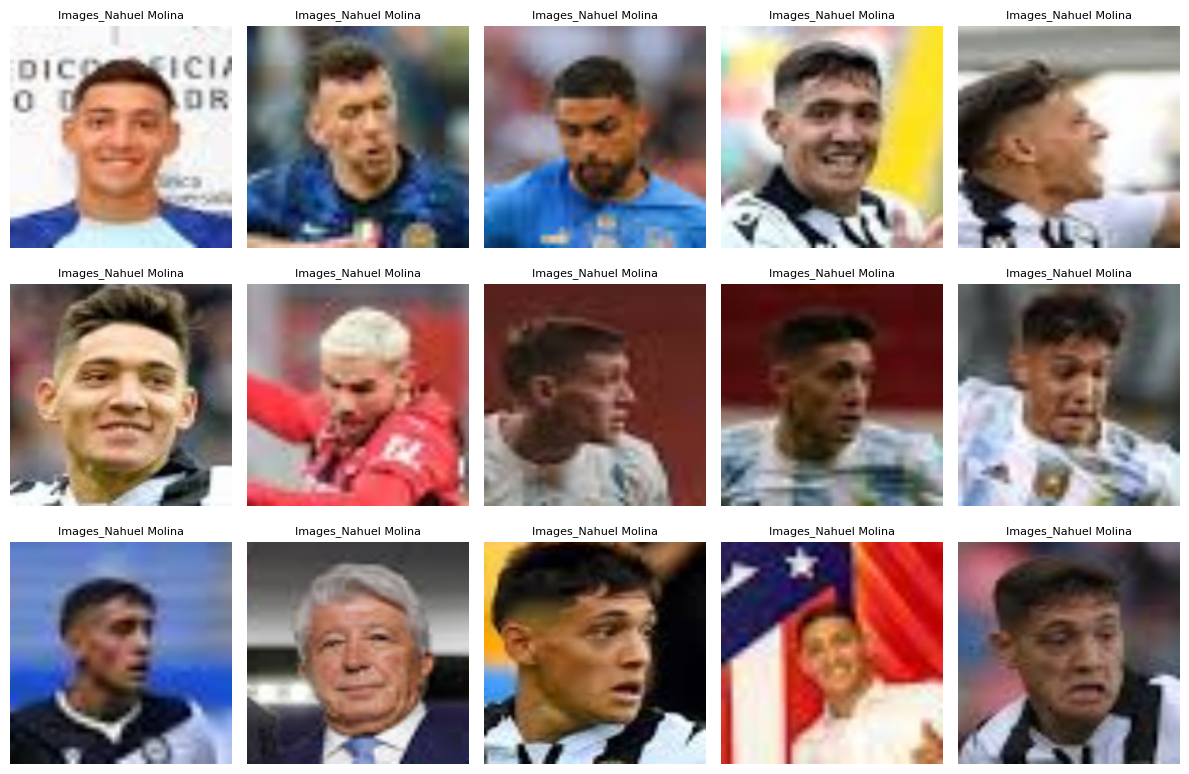

In [ ]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

argentina = []

for p in Path("/content/FIFA_2022_ONLY_FACES").rglob("*"):

    if p.suffix.lower() not in [".jpg",".jpeg",".png"]:
        continue

    if "argentina" in str(p).lower():
        argentina.append(p)

print("Encontradas:", len(argentina))

fig, axes = plt.subplots(
    3,
    5,
    figsize=(12,8)
)

for ax, img_path in zip(
    axes.flatten(),
    argentina[:15]
):

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(img)
    ax.axis("off")

    try:
        ax.set_title(
            img_path.parent.name,
            fontsize=8
        )
    except:
        pass

plt.tight_layout()
plt.show()